# SSNAL vs Vanilla PDHG on Two Moons

This notebook:
1. Verifies the new `ssnal_convex_clustering` implementation in `algorithms.py`.
2. Compares convergence against `vanilla_pdhg` on a two-moons graph.


In [17]:
from __future__ import annotations

from dataclasses import dataclass
import importlib

import sys
sys.path.insert(0, "/Users/chester/Documents/cc-net")


import matplotlib.pyplot as plt
import numpy as np
import torch
import graphlearning as gl
import sklearn.datasets as skdatasets

import algorithms as alg

alg = importlib.reload(alg)
vanilla_pdhg = alg.vanilla_pdhg
ssnal_convex_clustering = alg.ssnal_convex_clustering
from datasets.dataset_utils import graphlearning_to_pyg
from losses.losses import energy, energy_pdg, kkt_residuals, divergence
from models.model_utils import project_l2

torch.set_default_dtype(torch.float32)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cpu')

In [18]:
@dataclass
class SolverHistory:
    iters: list[int]
    obj: list[float]
    pdg: list[float]
    kkt: list[float]


def make_two_moons_graph(
    n_samples: int = 400,
    noise: float = 0.07,
    k_neighbors: int = 10,
    kernel: str = "gaussian",
    seed: int = 0,
):
    X_np, y_np = skdatasets.make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    W = gl.weightmatrix.knn(X_np, k=k_neighbors, kernel=kernel)
    W.setdiag(0)
    W.eliminate_zeros()
    data = graphlearning_to_pyg(X_np, W)

    X = data.x.to(DEVICE).float()
    edge_index = data.edge_index.to(DEVICE).long()
    w = data.edge_attr.to(DEVICE).float()
    y = torch.tensor(y_np, dtype=torch.long, device=DEVICE)
    return X, y, edge_index, w


In [19]:
def run_pdhg_history(
    X: torch.Tensor,
    edge_index: torch.Tensor,
    w: torch.Tensor,
    lam: float,
    iters: int,
    tau: float,
    sigma: float,
    use_extrapolation: bool = True,
    theta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, SolverHistory]:
    src, dst = edge_index
    sqrtw = w.sqrt()
    n, d = X.shape

    U = X.clone()
    U_bar = U.clone()
    P = torch.zeros(src.numel(), d, dtype=X.dtype, device=X.device)
    r = lam * sqrtw
    theta_eff = float(theta if use_extrapolation else 0.0)

    hist = SolverHistory(iters=[], obj=[], pdg=[], kkt=[])

    for k in range(iters):
        diff_bar = U_bar[src] - U_bar[dst]
        P_new = project_l2(P + tau * (sqrtw[:, None] * diff_bar), r)
        div = divergence(sqrtw[:, None] * P_new, src, dst, n)
        U_new = (U + sigma * (X - div)) / (1.0 + sigma)

        U_prev = U
        U = U_new
        P = P_new
        U_bar = U + theta_eff * (U - U_prev)

        hist.iters.append(k + 1)
        hist.obj.append(float(energy(U, X, src, dst, w, lam)))
        hist.pdg.append(float(energy_pdg(U, X, P, src, dst, w, lam)))
        hist.kkt.append(float(kkt_residuals(U, P, X, src, dst, w, lam)["kkt_rel"]))

    return U, P, hist


def run_ssnal_history(
    X: torch.Tensor,
    edge_index: torch.Tensor,
    w: torch.Tensor,
    lam: float,
    iters: int,
    tau: float,
    sigma: float,
    U0: torch.Tensor | None = None,
    P0: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor, SolverHistory]:
    alg_current = importlib.reload(alg)
    src, dst = edge_index
    n, d = X.shape
    sigma_k = max(float(sigma), 1e-6)

    Xk = X.clone() if U0 is None else U0.to(dtype=X.dtype, device=X.device).clone()
    if P0 is None:
        Zk = torch.zeros(src.numel(), d, dtype=X.dtype, device=X.device)
    else:
        sqrtw = w.sqrt().clamp_min(1e-12).view(-1, 1)
        Zk = sqrtw * P0.to(dtype=X.dtype, device=X.device)

    hist = SolverHistory(iters=[], obj=[], pdg=[], kkt=[])

    max_newton_iters = 30
    cg_max_iters = min(400, max(40, 2 * n))

    for k in range(iters):
        alm_epsilon_k = min(1e-2, 1.0 / float((k + 1) ** 2))
        subproblem_tol = alm_epsilon_k / max(1.0, sigma_k**0.5)
        Xk = alg_current._ssncg_subproblem(
            A=X,
            src=src,
            dst=dst,
            w=w,
            lam=lam,
            sigma_k=sigma_k,
            Zk=Zk,
            X0=Xk,
            tau=tau,
            max_newton_iters=max_newton_iters,
            cg_max_iters=cg_max_iters,
            stopping_tol=subproblem_tol,
        )

        Dk = alg_current._graph_difference(Xk, src, dst) + Zk / sigma_k
        Uk = alg_current._weighted_group_l2_shrinkage(Dk, (lam * w) / sigma_k)
        primal_residual = alg_current._graph_difference(Xk, src, dst) - Uk
        Zk = Zk + sigma_k * primal_residual

        P = Zk / w.sqrt().clamp_min(1e-12).view(-1, 1)

        hist.iters.append(k + 1)
        hist.obj.append(float(energy(Xk, X, src, dst, w, lam)))
        hist.pdg.append(float(energy_pdg(Xk, X, P, src, dst, w, lam)))
        hist.kkt.append(float(kkt_residuals(Xk, P, X, src, dst, w, lam)["kkt_rel"]))

    return Xk, P, hist


nodes=400, edges=2352, device=cpu


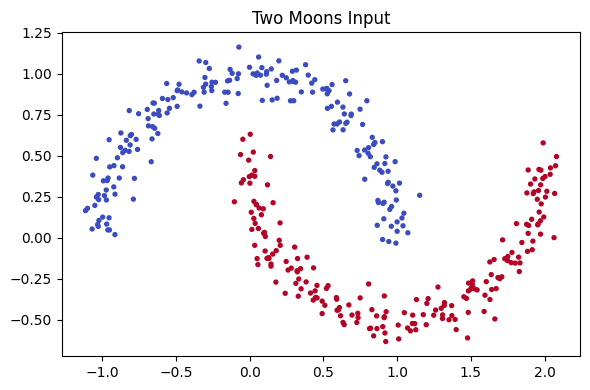

In [20]:
seed = 0
n_samples = 400
noise = 0.07
k_neighbors = 10
kernel = "gaussian"
lam = 1.0

pdhg_iters = 800
pdhg_tau = 0.25
pdhg_sigma = 0.25
warm_pdhg_iters = 100

ssnal_iters = 400
ssnal_tau = 0.35
ssnal_sigma = 0.5

X, y, edge_index, w = make_two_moons_graph(
    n_samples=n_samples,
    noise=noise,
    k_neighbors=k_neighbors,
    kernel=kernel,
    seed=seed,
)

print(f"nodes={X.shape[0]}, edges={edge_index.shape[1]}, device={X.device}")

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), s=8, cmap="coolwarm")
plt.title("Two Moons Input")
plt.tight_layout()
plt.show()


In [21]:
# API-level verification for SSNAL
alg_current = importlib.reload(alg)
U_ssnal_api, P_ssnal_api = alg_current.ssnal_convex_clustering(
    X=X,
    edge_index=edge_index,
    w=w,
    lam=lam,
    iters=ssnal_iters,
    tau=ssnal_tau,
    sigma=ssnal_sigma,
)

U_ssnal_trace, P_ssnal_trace, ssnal_hist = run_ssnal_history(
    X=X,
    edge_index=edge_index,
    w=w,
    lam=lam,
    iters=ssnal_iters,
    tau=ssnal_tau,
    sigma=ssnal_sigma,
)

u_diff = float((U_ssnal_api - U_ssnal_trace).abs().max())
p_diff = float((P_ssnal_api - P_ssnal_trace).abs().max())
print(f"max |U_api - U_trace| = {u_diff:.3e}")
print(f"max |P_api - P_trace| = {p_diff:.3e}")

src, dst = edge_index
print("SSNAL final metrics")
print("  objective:", float(energy(U_ssnal_api, X, src, dst, w, lam)))
print("  primal-dual gap:", float(energy_pdg(U_ssnal_api, X, P_ssnal_api, src, dst, w, lam)))
print("  kkt_rel:", float(kkt_residuals(U_ssnal_api, P_ssnal_api, X, src, dst, w, lam)["kkt_rel"]))


max |U_api - U_trace| = 0.000e+00
max |P_api - P_trace| = 0.000e+00
SSNAL final metrics
  objective: 6.319363594055176
  primal-dual gap: 6.628036499023438e-05
  kkt_rel: 0.01786639168858528


In [22]:
U_pdhg, P_pdhg, pdhg_hist = run_pdhg_history(
    X=X,
    edge_index=edge_index,
    w=w,
    lam=lam,
    iters=pdhg_iters,
    tau=pdhg_tau,
    sigma=pdhg_sigma,
)

print("PDHG final metrics")
print("  objective:", float(energy(U_pdhg, X, src, dst, w, lam)))
print("  primal-dual gap:", float(energy_pdg(U_pdhg, X, P_pdhg, src, dst, w, lam)))
print("  kkt_rel:", float(kkt_residuals(U_pdhg, P_pdhg, X, src, dst, w, lam)["kkt_rel"]))

U_pdhg_warm, P_pdhg_warm, _ = run_pdhg_history(
    X=X,
    edge_index=edge_index,
    w=w,
    lam=lam,
    iters=warm_pdhg_iters,
    tau=pdhg_tau,
    sigma=pdhg_sigma,
)

U_ssnal_warm_trace, P_ssnal_warm_trace, ssnal_warm_hist = run_ssnal_history(
    X=X,
    edge_index=edge_index,
    w=w,
    lam=lam,
    iters=ssnal_iters,
    tau=ssnal_tau,
    sigma=ssnal_sigma,
    U0=U_pdhg_warm,
    P0=P_pdhg_warm,
)

alg_current = importlib.reload(alg)
U_ssnal_warm_api, P_ssnal_warm_api = alg_current.ssnal_convex_clustering(
    X=X,
    edge_index=edge_index,
    w=w,
    lam=lam,
    iters=ssnal_iters,
    tau=ssnal_tau,
    sigma=ssnal_sigma,
    U0=U_pdhg_warm,
    P0=P_pdhg_warm,
)
u_warm_diff = float((U_ssnal_warm_api - U_ssnal_warm_trace).abs().max())
p_warm_diff = float((P_ssnal_warm_api - P_ssnal_warm_trace).abs().max())
print(f"max |U_warm_api - U_warm_trace| = {u_warm_diff:.3e}")
print(f"max |P_warm_api - P_warm_trace| = {p_warm_diff:.3e}")

print(f"\nSSNAL warm-start: PDHG pre-iterations = {warm_pdhg_iters}")
print("  objective:", float(energy(U_ssnal_warm_trace, X, src, dst, w, lam)))
print("  primal-dual gap:", float(energy_pdg(U_ssnal_warm_trace, X, P_ssnal_warm_trace, src, dst, w, lam)))
print("  kkt_rel:", float(kkt_residuals(U_ssnal_warm_trace, P_ssnal_warm_trace, X, src, dst, w, lam)["kkt_rel"]))


PDHG final metrics
  objective: 6.3197526931762695
  primal-dual gap: 0.0005092620849609375
  kkt_rel: 0.0605354979634285
max |U_warm_api - U_warm_trace| = 0.000e+00
max |P_warm_api - P_warm_trace| = 0.000e+00

SSNAL warm-start: PDHG pre-iterations = 100
  objective: 6.319364547729492
  primal-dual gap: 6.67572021484375e-05
  kkt_rel: 0.015388468280434608


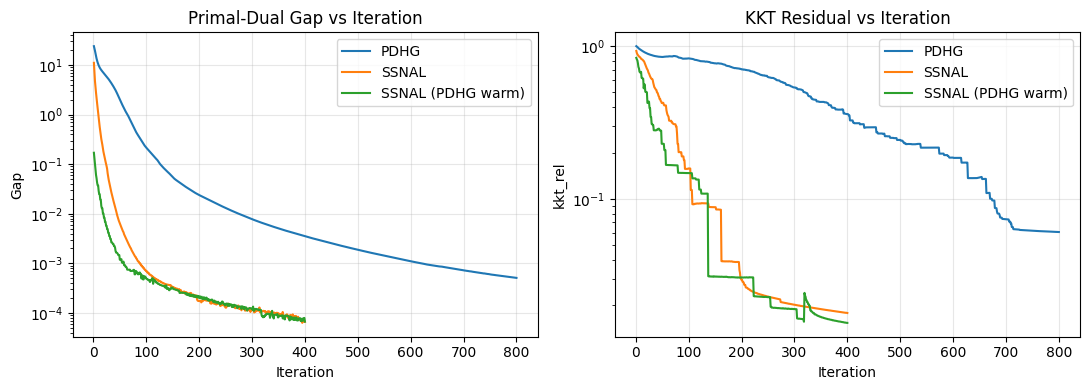

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(pdhg_hist.iters, pdhg_hist.pdg, label="PDHG")
axes[0].semilogy(ssnal_hist.iters, ssnal_hist.pdg, label="SSNAL")
axes[0].semilogy(ssnal_warm_hist.iters, ssnal_warm_hist.pdg, label="SSNAL (PDHG warm)")
axes[0].set_title("Primal-Dual Gap vs Iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Gap")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(pdhg_hist.iters, pdhg_hist.kkt, label="PDHG")
axes[1].semilogy(ssnal_hist.iters, ssnal_hist.kkt, label="SSNAL")
axes[1].semilogy(ssnal_warm_hist.iters, ssnal_warm_hist.kkt, label="SSNAL (PDHG warm)")
axes[1].set_title("KKT Residual vs Iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("kkt_rel")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [24]:
def first_hit(values: list[float], thresh: float) -> int | None:
    for i, v in enumerate(values, start=1):
        if np.isfinite(v) and v < thresh:
            return i
    return None

thresholds = [1e-1, 1e-2, 1e-3, 1e-4]
print("Gap threshold crossings (iteration only):")
for thr in thresholds:
    p_it = first_hit(pdhg_hist.pdg, thr)
    s_it = first_hit(ssnal_hist.pdg, thr)
    sw_it = first_hit(ssnal_warm_hist.pdg, thr)
    print(f"thr={thr:1.0e} | PDHG={p_it} | SSNAL={s_it} | SSNAL-warm={sw_it}")

print("\nFinal values:")
print(f"PDHG:  gap={pdhg_hist.pdg[-1]:.3e}, kkt={pdhg_hist.kkt[-1]:.3e}")
print(f"SSNAL: gap={ssnal_hist.pdg[-1]:.3e}, kkt={ssnal_hist.kkt[-1]:.3e}")
print(f"SSNAL-warm: gap={ssnal_warm_hist.pdg[-1]:.3e}, kkt={ssnal_warm_hist.kkt[-1]:.3e}")


Gap threshold crossings (iteration only):
thr=1e-01 | PDHG=127 | SSNAL=25 | SSNAL-warm=4
thr=1e-02 | PDHG=275 | SSNAL=45 | SSNAL-warm=20
thr=1e-03 | PDHG=621 | SSNAL=89 | SSNAL-warm=58
thr=1e-04 | PDHG=None | SSNAL=326 | SSNAL-warm=318

Final values:
PDHG:  gap=5.093e-04, kkt=6.054e-02
SSNAL: gap=6.628e-05, kkt=1.787e-02
SSNAL-warm: gap=6.676e-05, kkt=1.539e-02


### Notes
- This notebook compares convergence by iteration counts and residuals only.
- Runtime/timing experiments were removed as requested.
- Includes SSNAL warm-started from a short PDHG run.
